In [62]:
import torch

In [63]:
from torch import nn
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

In [64]:
training_data = datasets.FGVCAircraft(
    root = "data",
    split = "train",
    download = True,
    transform=v2.Compose([v2.ToImage(), v2.Resize((224, 224)), v2.ToDtype(torch.float32, scale=True)]),
)

testing_data = datasets.FGVCAircraft(
    root = "data",
    split = "test",
    download = True,
    transform=v2.Compose([v2.ToImage(), v2.Resize((224, 224)), v2.ToDtype(torch.float32, scale=True)]),
)

In [74]:
batch_size = 64

train_dataloader = DataLoader(training_data, shuffle=True, batch_size=batch_size)
test_dataloader = DataLoader(testing_data, batch_size=batch_size)

input_size = channels * height * width
aircraft [0] = 3 * 695 * 1024 (3 colors, 695 height, 1024 width but it varies by image)
resized to 64 * 64 for consistency and less needed weights

In [66]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(3 * 224 * 224, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, len(training_data.classes))
        )
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=150528, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=100, bias=True)
  )
)


torch.Size([3, 224, 224])


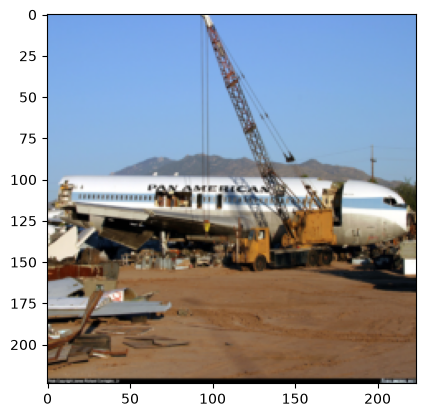

Label: 0


In [67]:
import matplotlib.pyplot as plt

img, label = training_data[4]
print(img.shape)
plt.imshow(img.permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

# # SGD with momentum
# optimizer = torch.optim.SGD(
#     model.parameters(), lr=0.01, momentum=0.9
# )

# Adam
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001
)

# # AdamW
# optimizer = torch.optim.AdamW(
#     model.parameters(), lr=0.001, weight_decay=0.01
# )

In [69]:
device = "cpu"

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0 or batch == len(dataloader) - 1:
            print(f"loss: {loss.item():.6f}  "f"[batch {batch + 1}/{len(dataloader)}]"
    )

In [70]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [71]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 4.582600  [batch 1/53]
loss: 4.683403  [batch 11/53]
loss: 4.636861  [batch 21/53]
loss: 4.726940  [batch 31/53]
loss: 4.730898  [batch 41/53]
loss: 4.665965  [batch 51/53]
loss: 4.579157  [batch 53/53]
Test Error: 
 Accuracy: 1.0%, Avg loss: 4.604393 

Epoch 2
-------------------------------
loss: 4.610062  [batch 1/53]
loss: 4.597047  [batch 11/53]
loss: 4.642001  [batch 21/53]
loss: 4.658845  [batch 31/53]
loss: 4.668852  [batch 41/53]
loss: 4.646163  [batch 51/53]
loss: 4.566156  [batch 53/53]
Test Error: 
 Accuracy: 1.4%, Avg loss: 4.604209 

Epoch 3
-------------------------------
loss: 4.610224  [batch 1/53]
loss: 4.606735  [batch 11/53]
loss: 4.608235  [batch 21/53]
loss: 4.619926  [batch 31/53]
loss: 4.635554  [batch 41/53]
loss: 4.641778  [batch 51/53]
loss: 4.573747  [batch 53/53]
Test Error: 
 Accuracy: 1.0%, Avg loss: 4.603871 

Epoch 4
-------------------------------
loss: 4.601541  [batch 1/53]
loss: 4.618283  [batch 11/53]
l

In [72]:
# Adam
optimizer = torch.optim.Adam(
    model.parameters(), lr=0.001
)

In [76]:
torch.manual_seed(42)

model = NeuralNetwork().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [77]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 4.595939  [batch 1/53]
loss: 4.988622  [batch 11/53]
loss: 4.740389  [batch 21/53]
loss: 4.725955  [batch 31/53]
loss: 4.699515  [batch 41/53]
loss: 4.780247  [batch 51/53]
loss: 4.561853  [batch 53/53]
Test Error: 
 Accuracy: 1.0%, Avg loss: 4.656006 

Epoch 2
-------------------------------
loss: 4.553960  [batch 1/53]
loss: 4.656544  [batch 11/53]
loss: 4.620726  [batch 21/53]
loss: 4.605740  [batch 31/53]
loss: 4.606080  [batch 41/53]
loss: 4.547578  [batch 51/53]
loss: 4.621365  [batch 53/53]
Test Error: 
 Accuracy: 1.6%, Avg loss: 4.610434 

Epoch 3
-------------------------------
loss: 4.669965  [batch 1/53]
loss: 4.638785  [batch 11/53]
loss: 4.606466  [batch 21/53]
loss: 4.627809  [batch 31/53]
loss: 4.572543  [batch 41/53]
loss: 4.560694  [batch 51/53]
loss: 4.614444  [batch 53/53]
Test Error: 
 Accuracy: 2.2%, Avg loss: 4.586108 

Epoch 4
-------------------------------
loss: 4.595221  [batch 1/53]
loss: 4.446518  [batch 11/53]
l